STEP 1:

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
#read counts data
expr = pd.read_csv("SRP_counts.tsv", sep="\t", index_col="Gene")
meta = pd.read_csv("metadata.tsv", sep="\t")

assert list(expr.columns) == meta.refinebio_accession_code.tolist() #make sure samples match in metadata and expr matrix
print("genes x samples:", expr.shape)

genes x samples: (43363, 335)


In [42]:
#read metadata and separate into brain areas and disorders
meta[["region", "dx"]] = meta.refinebio_subject.str.split("_", n=1, expand=True)
meta["donor"] = meta.refinebio_title.str.split("_").str[0]

print(pd.crosstab(meta.dx, meta.region))
print("unique donors:", meta.donor.nunique())

region            ancg  dlpfc  nacc
dx                                 
bipolar disorder    25     28    30
control             28     28    27
major depression    27     30    32
schizophrenia       27     28    25
unique donors: 96


In [43]:
#each library is the specific patient sample from each region sampled. Here I look for and merged duplicates
run_to_lib = meta.set_index("refinebio_accession_code").refinebio_title
print("duplicate runs:", run_to_lib.duplicated().sum())

expr_lib = expr.T.groupby(run_to_lib).mean().T
meta_lib = (meta.drop_duplicates("refinebio_title").set_index("refinebio_title").loc[expr_lib.columns])

print("genes x libraries:", expr_lib.shape)

#found 69 duplicates, so we actually have 266 libraries total

duplicate runs: 69
genes x libraries: (43363, 266)


In [44]:
#5 log-scale the data (the range of data before is to confirm the data is not log-scaled yet, only quantile normalized)
print("range before log:", expr_lib.values.min(), expr_lib.values.max())
log_expr = np.log2(expr_lib + 1)
#we have to add 1 or else log-scaling breaks with the negative values from quantile normalization

range before log: -0.1583617006285569 197.4761356701856


In [45]:
#how much variation do you see in the data? (per gene median expression ranges)
medians = log_expr.median(axis=1)
spread = log_expr.max(axis=1) - log_expr.min(axis=1)

print(medians.describe())
print("genes with median <= 0:", (medians <= 0).sum())
print(spread.describe())

count    43363.000000
mean         1.092880
std          1.154176
min         -0.098697
25%          0.181527
50%          0.767416
75%          1.723796
max          7.632822
dtype: float64
genes with median <= 0: 8165
count    43363.000000
mean         1.104323
std          0.650898
min          0.341434
25%          0.684684
50%          0.879574
75%          1.260153
max          6.202458
dtype: float64


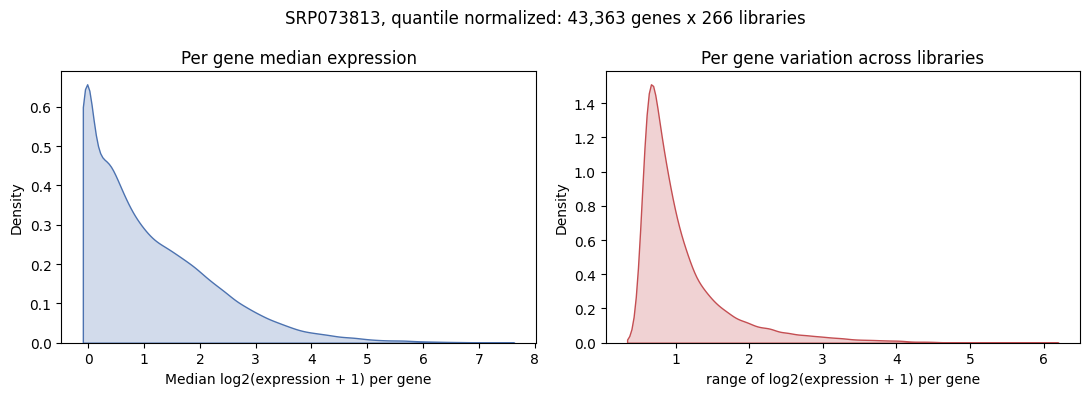

In [46]:
#density plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.kdeplot(medians, fill=True, cut=0, color="#4C72B0", ax=axes[0])
axes[0].set_xlabel("Median log2(expression + 1) per gene")
axes[0].set_ylabel("Density")
axes[0].set_title("Per gene median expression")

sns.kdeplot(spread, fill=True, cut=0, color="#C44E52", ax=axes[1])
axes[1].set_xlabel("range of log2(expression + 1) per gene")
axes[1].set_ylabel("Density")
axes[1].set_title("Per gene variation across libraries")

fig.suptitle(f"SRP073813, quantile normalized: {expr_lib.shape[0]:,} genes x {expr_lib.shape[1]} libraries")
fig.tight_layout()
fig.savefig("plots/step1_density_medians.png", dpi=200, bbox_inches="tight")

In [47]:
#convert the Ensembl IDs to gene names with mygene.
%pip install mygene
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(expr_lib.index.tolist(), scopes="ensembl.gene", fields="symbol", species="human")

res = pd.DataFrame(results)
print("rows returned:", len(res), "vs queried:", len(expr_lib))
print("multi-hit IDs:", res["query"].duplicated().sum())

#there's 28 duplicate names that we need to get rid of or else all the later genes are unmatched because of offset
symbols = (res.drop_duplicates("query")
              .set_index("query")["symbol"]
              .reindex(expr_lib.index))

print("no symbol:", symbols.isna().sum())
symbols.rename("symbol").rename_axis("ensembl_id").to_csv("gene_symbols.tsv", sep="\t")

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

rows returned: 43406 vs queried: 43363
multi-hit IDs: 43
no symbol: 10172


In [48]:
expr_lib.to_csv("data/expr_by_library.tsv.gz", sep="\t")
meta_lib.to_csv("data/meta_by_library.tsv", sep="\t")

STEP 2:

In [49]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

In [50]:
#load merged data from step 1 and then separates to do plots on anterior cingulate region
expr = pd.read_csv("data/expr_by_library.tsv.gz", sep="\t", index_col=0)
meta = pd.read_csv("data/meta_by_library.tsv", sep="\t", index_col=0)

sl = meta.index.str.extract(r"SL(\d+)")[0].astype(int).values
meta["batch"] = np.where(sl > 20000, "B", "A")

keep = meta[(meta.region == "ancg") & (meta.dx != "major depression")].copy()
keep["group"] = np.where(keep.dx == "control", "Control", "SZ+BPD")

print(keep.group.value_counts())
print(keep.dx.value_counts())

group
SZ+BPD     45
Control    22
Name: count, dtype: int64
dx
schizophrenia       23
control             22
bipolar disorder    22
Name: count, dtype: int64


In [51]:
#log scale and filter genes with zero expression (about 8000) before doing plots
log_expr = np.log2(expr[keep.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]
print("genes kept:", log_expr.shape[0])

genes kept: 35050


In [52]:
#select 500 most variable genes to do PCA
top = log_expr.var(axis=1).sort_values(ascending=False).index[:500]
X = log_expr.loc[top].T

In [53]:
pca = PCA(n_components=10).fit(X)
pcs = pca.transform(X)
var = pca.explained_variance_ratio_ * 100
print("variance explained (%):", var[:5].round(1))

variance explained (%): [38.2 13.7 11.   6.4  3.8]


In [54]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="pca").fit_transform(X)
um = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42).fit_transform(X)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [55]:
#plots

colors = {"Control": "#1f77b4", "Disorder": "#d62728"}
panels = [
    (pcs[:, :2], f"PC1 ({var[0]:.1f}% variance)", f"PC2 ({var[1]:.1f}% variance)", "PCA", "pca"),
    (tsne, "t-SNE 1", "t-SNE 2", "t-SNE (perplexity 15)", "tsne"),
    (um, "UMAP 1", "UMAP 2", "UMAP (n_neighbors 15)", "umap"),
]

for coords, xl, yl, title, fname in panels:
    fig, ax = plt.subplots(figsize=(6, 5))
    for g, c in colors.items():
        mask = (keep.group == g).values
        ax.scatter(coords[mask, 0], coords[mask, 1], c=c,
                   label=f"{g} (n={mask.sum()})", s=40, alpha=0.75,
                   edgecolor="k", linewidth=0.3)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"{title}: AnCg, control vs any disorder")
    ax.legend(title="Group")
    fig.savefig(f"plots/step2_{fname}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

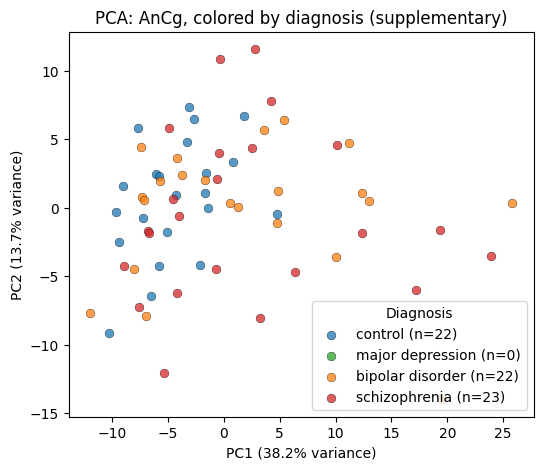

In [57]:
#extra plot separated by disease that shows how depression aligns with control, but bipolar and schizophrenia align more with each other
dx_colors = {
    "control": "#1f77b4",
    "major depression": "#2ca02c",
    "bipolar disorder": "#ff7f0e",
    "schizophrenia": "#d62728",
}

fig, ax = plt.subplots(figsize=(6, 5))
for d, c in dx_colors.items():
    mask = (keep.dx == d).values
    ax.scatter(pcs[mask, 0], pcs[mask, 1], c=c,
               label=f"{d} (n={mask.sum()})", s=40, alpha=0.75,
               edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title("PCA: AnCg, colored by diagnosis (supplementary)")
ax.legend(title="Diagnosis")
fig.savefig("plots/step2_pca_by_diagnosis.png", dpi=200, bbox_inches="tight")

Step 3: Control vs any disorder gave no significant genes, so I chose to do control vs schizophrenia + bipolar (since depression aligns really well with the control it was dropped from "disorders")

In [58]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [59]:
#log scale and filter just like step 2, we have 67 libraries since depression was dropped
log_expr = np.log2(expr[keep.index] + 1)
log_expr = log_expr[log_expr.median(axis=1) > 0]
print(log_expr.shape)

(35050, 67)


In [60]:
#split samples into control and schizophrenia + bipolar. difference in means is the log2 fold change.
ctrl = log_expr.loc[:, keep.group == "Control"]
case = log_expr.loc[:, keep.group == "SZ+BPD"]

log2fc = case.mean(axis=1) - ctrl.mean(axis=1)

In [61]:
#run a welch t test for each gene.
tt = stats.ttest_ind(case, ctrl, axis=1, equal_var=False)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


In [62]:
#combine results into one table and apply the p-value correction (benjamini-hochberg) to account for random chance
res = pd.DataFrame({
    "log2FC": log2fc,
    "t": tt.statistic,
    "pvalue": tt.pvalue,
}, index=log_expr.index)

res["padj"] = multipletests(res.pvalue, method="fdr_bh")[1]

In [63]:
#call genes up or down regulated (or not signicant change), as long as they have a adjusted p below 0.05 and log fold change above 0.1
symbols = pd.read_csv("gene_symbols.tsv", sep="\t", index_col=0)["symbol"]
res.insert(0, "symbol", symbols.reindex(res.index))

res["significant"] = np.where(
    (res.padj < 0.05) & (res.log2FC > 0.1), "Up",
    np.where((res.padj < 0.05) & (res.log2FC < -0.1), "Down", "Not significant"))

print(res.significant.value_counts())

significant
Not significant    32231
Down                1692
Up                  1127
Name: count, dtype: int64


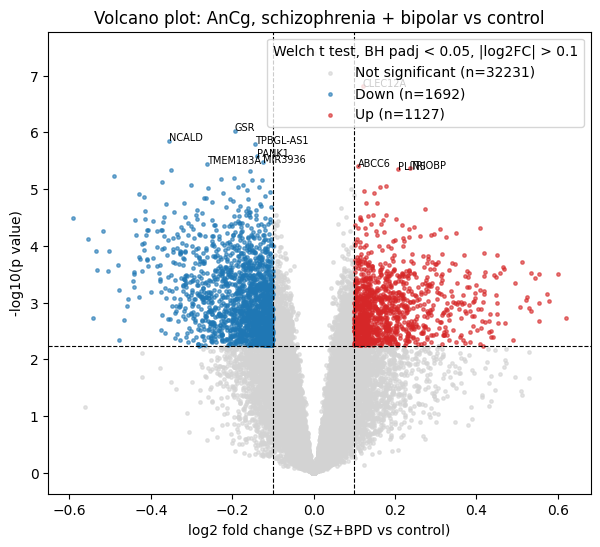

In [64]:
#volcano plot
res["neglog10p"] = -np.log10(res.pvalue)

colors = {"Not significant": "lightgray", "Down": "#1f77b4", "Up": "#d62728"}
fig, ax = plt.subplots(figsize=(7, 6))
for lab, c in colors.items():
    sub = res[res.significant == lab]
    ax.scatter(sub.log2FC, sub.neglog10p, c=c, s=6, alpha=0.6,
               label=f"{lab} (n={len(sub)})")

p_cut = res.loc[res.padj < 0.05, "pvalue"].max()
ax.axhline(-np.log10(p_cut), ls="--", c="k", lw=0.8)
ax.axvline(0.1, ls="--", c="k", lw=0.8)
ax.axvline(-0.1, ls="--", c="k", lw=0.8)

for gene, row in res[res.significant != "Not significant"].nsmallest(10, "pvalue").iterrows():
    ax.annotate(row.symbol if pd.notna(row.symbol) else gene,
                (row.log2FC, row.neglog10p), fontsize=7)

ax.set_xlabel("log2 fold change (SZ+BPD vs control)")
ax.set_ylabel("-log10(p value)")
ax.set_title("Volcano plot: AnCg, schizophrenia + bipolar vs control")
ax.legend(title="Welch t test, BH padj < 0.05, |log2FC| > 0.1")
fig.savefig("plots/step3_volcano.png", dpi=200, bbox_inches="tight")

In [65]:
#save full results tabe and top 50 most significant genes. Table should be used for enrichment in step 5.
res = res.sort_values("pvalue")
res.drop(columns="neglog10p").to_csv("results-alice/step3_DE_results_all.tsv", sep="\t")

top50 = res[res.significant != "Not significant"].head(50)
top50.drop(columns="neglog10p").to_csv("results-alice/step3_top50_DE_genes.tsv", sep="\t")
top50[["symbol", "log2FC", "pvalue", "padj", "significant"]]

,symbol,log2FC,pvalue,padj,significant
Gene,,,,,
ENSG00000172322,CLEC12A,0.120650,1.552423e-07,0.002721,Up
ENSG00000104687,GSR,-0.193907,9.381005e-07,0.010960,Down
ENSG00000104490,NCALD,-0.355675,1.396624e-06,0.011116,Down
ENSG00000255136,TPBGL-AS1,-0.143147,1.585667e-06,0.011116,Down
ENSG00000152782,PANK1,-0.139014,2.626626e-06,0.012205,Down
ENSG00000263597,MIR3936,-0.123970,3.335542e-06,0.012205,Down
ENSG00000163444,TMEM183A,-0.261508,3.563275e-06,0.012205,Down
ENSG00000091262,ABCC6,0.108856,3.987279e-06,0.012205,Up
ENSG00000100106,TRIOBP,0.236528,4.263292e-06,0.012205,Up


Step 4:

In [66]:
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import fcluster

In [67]:
#select the significant genes and z score to map the z-scores, not total expression
sig_genes = res.index[res.significant != "Not significant"]
mat = log_expr.loc[sig_genes]

z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1), axis=0)
print(z.shape)

(2819, 67)


In [68]:
#colors
group_pal = {"Control": "#1b9e77", "SZ+BPD": "#7570b3"}
dx_pal = {"control": "#1b9e77", "schizophrenia": "#d95f02", "bipolar disorder": "#e6ab02"}
dir_pal = {"Up": "#b2182b", "Down": "#2166ac"}

col_colors = pd.DataFrame({
    "Group": keep.group.map(group_pal),
    "Diagnosis": keep.dx.map(dx_pal),
}, index=keep.index)

row_colors = res.loc[sig_genes, "significant"].map(dir_pal).rename("Direction")

/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


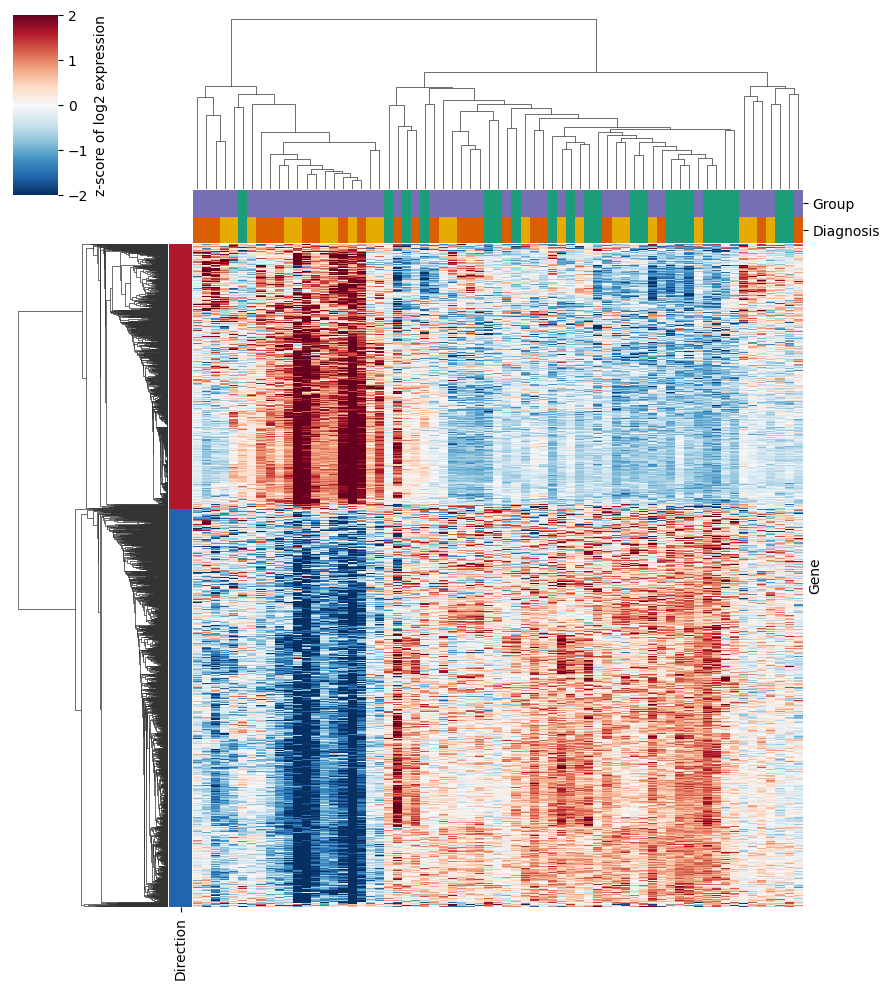

In [69]:
#draw the clustered heatmap
g = sns.clustermap(
    z,
    col_colors=col_colors,
    row_colors=row_colors,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    method="average", metric="correlation",
    xticklabels=False, yticklabels=False,
    figsize=(9, 10),
    cbar_kws={"label": "z-score of log2 expression"},
)

In [70]:
#add legend, labels, and title, and save to plots
handles = (
    [Patch(color="none", label="Group")]
    + [Patch(color=c, label=l) for l, c in group_pal.items()]
    + [Patch(color="none", label=""), Patch(color="none", label="Diagnosis")]
    + [Patch(color=c, label=l) for l, c in dx_pal.items()]
    + [Patch(color="none", label=""), Patch(color="none", label="Direction")]
    + [Patch(color=c, label=f"{l} in SZ+BPD") for l, c in dir_pal.items()]
)
g.ax_heatmap.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.15, 1.3), frameon=False, fontsize=8)

g.fig.suptitle(f"{len(sig_genes):,} significant genes, AnCg SZ+BPD vs control", y=1.02)
g.ax_heatmap.set_xlabel(f"Libraries (n={z.shape[1]})")
g.ax_heatmap.set_ylabel("Genes")
g.savefig("plots/step4_heatmap.png", dpi=200, bbox_inches="tight")

In [71]:
#cut sample into two clusters to see what the clustering separated
clusters = fcluster(g.dendrogram_col.linkage, 2, "maxclust")
print(pd.crosstab(pd.Series(clusters, index=z.columns, name="cluster"), keep.dx))
print(pd.crosstab(pd.Series(clusters, index=z.columns, name="cluster"), keep.batch))

dx       bipolar disorder  control  schizophrenia
cluster                                          
1                      10        1             10
2                      12       21             13
batch     A   B
cluster        
1        19   2
2        35  11


Step 5:

In [72]:
import os
import pandas as pd

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

#background/universe:
background_genes = pd.Series(
    res.index.astype(str).str.replace(r"\.\d+$", "", regex=True),
    name="ensembl_id"
).drop_duplicates()

#input list:
de_genes = pd.Series(
    res.index[res["significant"] != "Not significant"]
       .astype(str)
       .str.replace(r"\.\d+$", "", regex=True),
    name="ensembl_id"
).drop_duplicates()

print("Genes tested / background:", len(background_genes))
print("Significant DE genes:", len(de_genes))
print("\nFirst few DE genes:")
print(de_genes.head(10).to_list())

background_genes.to_frame().to_csv(
    "results/ANCG_SZBPD_vs_control_background_genes.tsv",
    sep="\t",
    index=False
)

de_genes.to_frame().to_csv(
    "results/ANCG_SZBPD_vs_control_DE_genes.tsv",
    sep="\t",
    index=False
)

Genes tested / background: 35050
Significant DE genes: 2819

First few DE genes:
['ENSG00000172322', 'ENSG00000104687', 'ENSG00000104490', 'ENSG00000255136', 'ENSG00000152782', 'ENSG00000263597', 'ENSG00000163444', 'ENSG00000091262', 'ENSG00000100106', 'ENSG00000214456']


In [73]:
!apt-get update -qq
!apt-get install -y -qq r-base r-base-dev
!pip install -q rpy2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [74]:
%load_ext rpy2.ipython

In [76]:
%%R

if (!requireNamespace("BiocManager", quietly = TRUE)) {
  install.packages("BiocManager", repos = "https://cloud.r-project.org")
}

options(repos = BiocManager::repositories())

unlink(
  file.path(.libPaths()[1], "00LOCK*"),
  recursive = TRUE,
  force = TRUE
)

print(R.version.string)
print(BiocManager::version())
print(.libPaths())

BiocManager::install(
  "org.Hs.eg.db",
  ask = FALSE,
  update = FALSE,
  force = TRUE
)

[1] "R version 4.6.1 (2026-06-24)"
[1] ‘3.23’
[1] "/usr/local/lib/R/site-library" "/usr/lib/R/site-library"      
[3] "/usr/lib/R/library"           


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    BioCsoft: https://bioconductor.org/packages/3.23/bioc
    BioCann: https://bioconductor.org/packages/3.23/data/annotation
    BioCexp: https://bioconductor.org/packages/3.23/data/experiment
    BioCworkflows: https://bioconductor.org/packages/3.23/workflows
    BioCbooks: https://bioconductor.org/packages/3.23/books
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'org.Hs.eg.db'
trying URL 'https://bioconductor.org/packages/3.23/data/annotation/src/contrib/org.Hs.eg.db_3.23.1.tar.gz'
Content type 'application/x-gzip' length 103790170 bytes (99.0 MB)
downloaded 99

In [77]:
%%R

library(org.Hs.eg.db)

cat("org.Hs.eg.db installed and loaded successfully")

org.Hs.eg.db installed and loaded successfully.


Loading required package: AnnotationDbi
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min

Loading required package: Biobase
Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'b

In [78]:
%%R

BiocManager::install(
  "clusterProfiler",
  ask = FALSE,
  update = FALSE,
  force = TRUE
)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    BioCsoft: https://bioconductor.org/packages/3.23/bioc
    BioCann: https://bioconductor.org/packages/3.23/data/annotation
    BioCexp: https://bioconductor.org/packages/3.23/data/experiment
    BioCworkflows: https://bioconductor.org/packages/3.23/workflows
    BioCbooks: https://bioconductor.org/packages/3.23/books
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'clusterProfiler'
also installing the dependencies ‘DOSE’, ‘enrichplot’, ‘GOSemSim’

trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/DOSE_4.6.0.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/enrichplot_1.32.0.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/GOSemSim_2.38.3.tar.gz'
trying URL 'https://bioconductor.org

In [79]:
%%R

library(clusterProfiler)
library(org.Hs.eg.db)

cat("clusterProfiler is installed and ready")

clusterProfiler is installed and ready.



clusterProfiler v4.20.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320

Attaching package: ‘clusterProfiler’

The following object is masked from ‘package:AnnotationDbi’:

    select

The following object is masked from ‘package:IRanges’:

    slice

The following object is masked from ‘package:S4Vectors’:

    rename

The following object is masked from ‘package:stats’:

    filter



In [80]:
%%R

library(clusterProfiler)
library(org.Hs.eg.db)

de_genes <- read.delim(
  "results/ANCG_SZBPD_vs_control_DE_genes.tsv",
  sep = "\t",
  stringsAsFactors = FALSE
)$ensembl_id

background_genes <- read.delim(
  "results/ANCG_SZBPD_vs_control_background_genes.tsv",
  sep = "\t",
  stringsAsFactors = FALSE
)$ensembl_id

de_genes <- unique(na.omit(as.character(de_genes)))
background_genes <- unique(na.omit(as.character(background_genes)))

de_genes <- intersect(de_genes, background_genes)

cat("DE genes submitted:", length(de_genes), "\n")
cat("Background genes submitted:", length(background_genes), "\n")

# Gene Ontology enrichment
go_bp <- enrichGO(
  gene = de_genes,
  universe = background_genes,
  OrgDb = org.Hs.eg.db,
  keyType = "ENSEMBL",
  ont = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff = 0.05,
  qvalueCutoff = 0.05,
  minGSSize = 10,
  maxGSSize = 500,
  readable = TRUE
)

go_bp_results <- as.data.frame(go_bp)

cat("Significant GO Biological Process terms:", nrow(go_bp_results), "\n")
print(head(go_bp_results, 15))

write.table(
  go_bp_results,
  file = "results/clusterProfiler_GO_BP_ANCG_SZBPD_vs_control.tsv",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE
)

DE genes submitted: 2819 
Background genes submitted: 35050 
Significant GO Biological Process terms: 82 
                   ID                                           Description
GO:0099504 GO:0099504                                synaptic vesicle cycle
GO:0050804 GO:0050804          modulation of chemical synaptic transmission
GO:0099177 GO:0099177                regulation of trans-synaptic signaling
GO:0099003 GO:0099003                 vesicle-mediated transport in synapse
GO:0061564 GO:0061564                                      axon development
GO:0048667 GO:0048667 cell morphogenesis involved in neuron differentiation
GO:0007409 GO:0007409                                          axonogenesis
GO:0072657 GO:0072657                      protein localization to membrane
GO:0007218 GO:0007218                        neuropeptide signaling pathway
GO:1990778 GO:1990778                protein localization to cell periphery
GO:0008038 GO:0008038                                    n

'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns
In addition: Warning messages:
1: In bitr(gene, fromType = fromType, toType = "ENTREZID", OrgDb = OrgDb) :
  16.99% of input gene IDs are fail to map...
2: In bitr(gene, fromType = fromType, toType = "ENTREZID", OrgDb = OrgDb) :
  29.19% of input gene IDs are fail to map...


In [81]:
import os

print(os.listdir("results"))

['ANCG_SZBPD_vs_control_background_genes.tsv', 'ANCG_SZBPD_vs_control_DE_genes.tsv', 'clusterProfiler_GO_BP_ANCG_SZBPD_vs_control.tsv']


In [85]:
import pandas as pd

go_results = pd.read_csv(
    "results/clusterProfiler_GO_BP_ANCG_SZBPD_vs_control.tsv",
    sep="\t"
)

step5_table = (
    go_results
    .sort_values("p.adjust", ascending=True)
    .loc[
        :,
        ["ID", "Description", "Count", "FoldEnrichment", "p.adjust"]
    ]
    .head(15)
    .rename(columns={
        "ID": "GO ID",
        "Description": "GO Biological Process",
        "Count": "DE Gene Count",
        "FoldEnrichment": "Fold Enrichment",
        "p.adjust": "BH FDR-adjusted p-value"
    })
    .reset_index(drop=True)
)

step5_table["Fold Enrichment"] = step5_table["Fold Enrichment"].round(2)
step5_table["BH FDR-adjusted p-value"] = step5_table[
    "BH FDR-adjusted p-value"
].map(lambda x: f"{x:.2e}")

display(step5_table)

,GO ID,GO Biological Process,DE Gene Count,Fold Enrichment,BH FDR-adjusted p-value
0,GO:0099504,synaptic vesicle cycle,55,2.34,4.81e-06
1,GO:0050804,modulation of chemical synaptic transmission,96,1.82,6.56e-06
2,GO:0099177,regulation of trans-synaptic signaling,96,1.81,6.56e-06
3,GO:0099003,vesicle-mediated transport in synapse,58,2.14,1.60e-05
4,GO:0061564,axon development,84,1.84,2.01e-05
5,GO:0048667,cell morphogenesis involved in neuron differen...,92,1.77,2.51e-05
6,GO:0007409,axonogenesis,75,1.87,3.73e-05
7,GO:0072657,protein localization to membrane,83,1.72,2.82e-04
8,GO:0007218,neuropeptide signaling pathway,31,2.57,2.82e-04
9,GO:1990778,protein localization to cell periphery,69,1.78,5.57e-04
